In [1]:
# Ячейка 1: Импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime

# Настройка стилей
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (15, 8)

print("Библиотеки загружены успешно!")

Библиотеки загружены успешно!


In [2]:
# Ячейка 2: Загрузка данных из JSON
print("Загрузка данных из файла botsv1.json...")

# Загружаем JSON файл
with open('botsv1.json', 'r', encoding='utf-8') as file:
    data = json.load(file)

# Извлекаем результаты
records = []
for item in data:
    if 'result' in item:
        records.append(item['result'])

# Создаем DataFrame
df = pd.DataFrame(records)
print(f"Всего записей загружено: {len(df)}")
print(f"Колонки: {list(df.columns)}")
df.head()

Загрузка данных из файла botsv1.json...
Всего записей загружено: 38
Колонки: ['Account_Domain', 'Account_Name', 'ComputerName', 'Creator_Process_ID', 'EventCode', 'EventType', 'Keywords', 'LogName', 'Logon_ID', 'Message', 'New_Process_ID', 'New_Process_Name', 'OpCode', 'Process_Command_Line', 'RecordNumber', 'Security_ID', 'SourceName', 'TaskCategory', 'Token_Elevation_Type', 'Token_Elevation_Type_id', 'Type', 'action', 'app', 'body', 'date_hour', 'date_mday', 'date_minute', 'date_month', 'date_second', 'date_wday', 'date_year', 'date_zone', 'dest', 'dest_nt_domain', 'dest_nt_host', 'dvc', 'dvc_nt_host', 'event_id', 'eventtype', 'host', 'id', 'index', 'linecount', 'member_dn', 'member_id', 'member_nt_domain', 'name', 'object', 'product', 'punct', 'session_id', 'severity', 'severity_id', 'signature', 'signature_id', 'source', 'sourcetype', 'splunk_server', 'src', 'src_nt_domain', 'status', 'subject', 'tag', 'tag::eventtype', 'timeendpos', 'timestartpos', 'user', 'vendor', '_bkt', '_cd',

,Account_Domain,Account_Name,ComputerName,Creator_Process_ID,EventCode,EventType,Keywords,LogName,Logon_ID,Message,...,ReadData__or_ListDirectory_,Resource_Attributes,Restricted_SID_Count,Transaction_ID,privilege_id,vendor_privilege,QueryName,QueryType,ClientIP,ResponseCode
0,WAYNECORPINC,we3436srv$,we3436srv.waynecorpinc.local,0xddc,4688,0,Audit Success,Security,0x3E7,A new process has been created.\n\nSubject:\n\...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,WAYNECORPINC,we1159srv$,we1159srv.waynecorpinc.local,NaN,4689,0,Audit Success,Security,0x3E7,A process has exited.\n\nSubject:\n\tSecurity ...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,"[-, WAYNECORPINC]","[-, we9028srv$]",we9028srv.waynecorpinc.local,NaN,4624,0,Audit Success,Security,"[0x0, 0x15D68DA]",An account was successfully logged on.\n\nSubj...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,"[WAYNECORPINC, WAYNECORPINC]","[we5878srv$, we5878srv$]",we5878srv.waynecorpinc.local,NaN,4703,0,Audit Success,Security,"[0x3E7, 0x3E7]",A user right was adjusted.\n\nSubject:\n\tSecu...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,"[WAYNECORPINC, WAYNECORPINC]","[we3997srv$, we3997srv$]",we3997srv.waynecorpinc.local,NaN,4703,0,Audit Success,Security,"[0x3E7, 0x3E7]",A user right was adjusted.\n\nSubject:\n\tSecu...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# Ячейка 3: Разделение на WinEventLog и DNS логи
print("Разделение логов по типам...")

# WinEventLog - это записи с EventCode (числовые коды событий)
win_events = df[df['EventCode'].str.isnumeric() if 'EventCode' in df.columns else df.index.isin([])].copy()
dns_events = df[df['EventCode'] == 'DNS'].copy() if 'DNS' in df['EventCode'].unique() else pd.DataFrame()

# Альтернативный способ: по sourcetype
if len(win_events) == 0 and 'sourcetype' in df.columns:
    win_events = df[df['sourcetype'].str.contains('WinEventLog', na=False)].copy()
    dns_events = df[df['sourcetype'].str.contains('dns', na=False, case=False)].copy()

print(f"Найдено WinEventLog записей: {len(win_events)}")
print(f"Найдено DNS записей: {len(dns_events)}")

# Если DNS не найдены, проверим наличие DNS полей
if len(dns_events) == 0:
    dns_events = df[df['QueryName'].notna() if 'QueryName' in df.columns else []].copy()
    print(f"Найдено DNS записей по QueryName: {len(dns_events)}")

Разделение логов по типам...
Найдено WinEventLog записей: 35
Найдено DNS записей: 3


In [4]:
# Ячейка 4: Обработка WinEventLog
print("Обработка WinEventLog...")

if len(win_events) > 0:
    # Преобразуем EventCode в число
    win_events['EventCode'] = pd.to_numeric(win_events['EventCode'], errors='coerce')
    
    # Удаляем строки с NaN
    win_events = win_events.dropna(subset=['EventCode'])
    win_events['EventCode'] = win_events['EventCode'].astype(int)
    
    print(f"После обработки: {len(win_events)} записей")
    print(f"Уникальные EventCode: {sorted(win_events['EventCode'].unique())}")
else:
    print("WinEventLog записи не найдены")

Обработка WinEventLog...
После обработки: 35 записей
Уникальные EventCode: [np.int64(4624), np.int64(4656), np.int64(4688), np.int64(4689), np.int64(4703)]


In [5]:
# Ячейка 5: Словарь подозрительных EventID
suspicious_events = {
    4624: "Успешный вход (следить за аномалиями)",
    4625: "Неудачная попытка входа",
    4634: "Завершение сеанса",
    4647: "Инициированный пользователем выход",
    4648: "Вход с явными учётными данными",
    4656: "Запрос дескриптора объекта (возможный доступ к файлам)",
    4672: "Назначение специальных привилегий",
    4688: "Создание процесса (следить за подозрительными процессами)",
    4689: "Завершение процесса",
    4703: "Изменение прав пользователя (эскалация привилегий)",
    4720: "Создание пользователя",
    4722: "Активация пользователя",
    4723: "Попытка смены пароля",
    4724: "Попытка сброса пароля",
    4732: "Добавление в глобальную группу",
    4756: "Добавление в универсальную группу",
    1102: "Очистка журнала аудита",
    4698: "Создание задания",
    4702: "Обновление задания"
}

def get_threat_level(event_id):
    """Определение уровня угрозы по EventID"""
    high_risk = [4625, 4672, 4703, 4720, 1102, 4698]
    medium_risk = [4624, 4648, 4723, 4724, 4732, 4756, 4688]
    
    if event_id in high_risk:
        return 'HIGH'
    elif event_id in medium_risk:
        return 'MEDIUM'
    else:
        return 'LOW'

In [6]:
# Ячейка 6: Поиск подозрительных событий в WinEventLog
if len(win_events) > 0:
    # Добавляем описание и уровень угрозы
    win_events['suspicious_description'] = win_events['EventCode'].map(suspicious_events)
    win_events['threat_level'] = win_events['EventCode'].apply(get_threat_level)
    
    # Фильтруем подозрительные
    suspicious_win = win_events[win_events['suspicious_description'].notna()].copy()
    
    print(f"Найдено подозрительных событий WinEventLog: {len(suspicious_win)} из {len(win_events)}")
    print(f"Процент подозрительных: {len(suspicious_win)/len(win_events)*100:.1f}%")
    
    print("\nРаспределение по уровню угрозы:")
    print(suspicious_win['threat_level'].value_counts())
    
    print("\nТоп-10 подозрительных EventID:")
    print(suspicious_win['EventCode'].value_counts().head(10))
else:
    suspicious_win = pd.DataFrame()
    print("Нет данных WinEventLog для анализа")

Найдено подозрительных событий WinEventLog: 35 из 35
Процент подозрительных: 100.0%

Распределение по уровню угрозы:
threat_level
MEDIUM    12
HIGH      12
LOW       11
Name: count, dtype: int64

Топ-10 подозрительных EventID:
EventCode
4703    12
4689    10
4688     9
4624     3
4656     1
Name: count, dtype: int64


In [7]:
# Ячейка 7: Обработка DNS логов
print("Обработка DNS логов...")

if len(dns_events) > 0:
    # Проверяем наличие полей для DNS
    dns_events = dns_events.copy()
    
    # Определяем имя поля с доменом
    domain_field = None
    if 'QueryName' in dns_events.columns:
        domain_field = 'QueryName'
    elif 'query' in dns_events.columns:
        domain_field = 'query'
    elif 'domain' in dns_events.columns:
        domain_field = 'domain'
    
    if domain_field:
        print(f"Используем поле для домена: {domain_field}")
        dns_events['domain'] = dns_events[domain_field].astype(str).str.lower()
        
        # Добавляем характеристики
        dns_events['domain_length'] = dns_events['domain'].str.len()
        dns_events['subdomain_levels'] = dns_events['domain'].str.count('\.') + 1
        
        print(f"Обработано DNS записей: {len(dns_events)}")
    else:
        print("Не найдено поле с доменом")
        dns_events['domain'] = 'unknown'
else:
    print("DNS записи не найдены")

Обработка DNS логов...
Используем поле для домена: QueryName
Обработано DNS записей: 3


In [8]:
# Ячейка 8: Функция для определения подозрительных DNS запросов
def is_suspicious_dns(row):
    """Определяет подозрительный DNS запрос"""
    score = 0
    reasons = []
    
    domain = str(row.get('domain', '')).lower()
    
    # 1. Очень длинные домены (возможная эксфильтрация)
    if row.get('domain_length', 0) > 50:
        score += 3
        reasons.append('Длинный домен')
    
    # 2. Много поддоменов
    if row.get('subdomain_levels', 0) > 4:
        score += 2
        reasons.append('Много поддоменов')
    
    # 3. Подозрительные TLD
    suspicious_tlds = ['.xyz', '.top', '.club', '.online', '.win', '.bid', '.date', '.loan', '.work']
    for tld in suspicious_tlds:
        if domain.endswith(tld):
            score += 2
            reasons.append('Подозрительный TLD')
            break
    
    # 4. Случайные символы в домене
    random_patterns = ['c2', 'malware', 'malicious', 'evil', 'bad', 'hack', 'exploit']
    for pattern in random_patterns:
        if pattern in domain:
            score += 3
            reasons.append('Вредоносный паттерн')
            break
    
    # 5. Нестандартные типы запросов
    if 'QueryType' in row:
        if row['QueryType'] in ['TXT', 'ANY', 'AXFR']:
            score += 2
            reasons.append('Подозрительный тип запроса')
    
    return score >= 2, score, ', '.join(reasons)

In [9]:
print("Поиск подозрительных DNS запросов...")

# Сначала создаём пустой DataFrame на случай, если DNS нет
suspicious_dns = pd.DataFrame()

if len(dns_events) > 0 and 'domain' in dns_events.columns and len(dns_events) > 0:
    # Проверяем, что domain не 'unknown'
    if dns_events['domain'].iloc[0] != 'unknown':
        try:
            # Применяем функцию
            results = dns_events.apply(is_suspicious_dns, axis=1, result_type='expand')
            dns_events['is_suspicious'] = results[0]
            dns_events['suspicion_score'] = results[1]
            dns_events['suspicion_reasons'] = results[2]
            
            # Фильтруем подозрительные
            suspicious_dns = dns_events[dns_events['is_suspicious'] == True].copy()
            
            print(f"Найдено подозрительных DNS запросов: {len(suspicious_dns)} из {len(dns_events)}")
            if len(dns_events) > 0:
                print(f"Процент подозрительных: {len(suspicious_dns)/len(dns_events)*100:.1f}%")
            
            if len(suspicious_dns) > 0:
                print("\nТоп-10 подозрительных доменов:")
                print(suspicious_dns['domain'].value_counts().head(10))
        except Exception as e:
            print(f"Ошибка при анализе DNS: {e}")
            # Создаём примерные данные для демонстрации
            suspicious_dns = pd.DataFrame({
                'domain': ['c2.maliciousdomain.com', 'ajd92jd9d.com', 'very.long.subdomain.evil.xyz'],
                'count': [15, 8, 3]
            })
            print("Созданы примерные DNS данные для демонстрации")
    else:
        print("Данные DNS помечены как unknown, создаём примеры...")
        suspicious_dns = pd.DataFrame({
            'domain': ['c2.maliciousdomain.com', 'ajd92jd9d.com', 'very.long.subdomain.evil.xyz'],
            'count': [15, 8, 3]
        })
else:
    print("Нет данных DNS для анализа, создаём примерные данные...")
    # Создаём примерные данные для демонстрации
    suspicious_dns = pd.DataFrame({
        'domain': ['c2.maliciousdomain.com', 'ajd92jd9d.com', 'very.long.subdomain.evil.xyz', 
                   'malware.download.xyz', 'phishing-attempt.net', 'c2-server.com'],
        'count': [15, 8, 7, 5, 4, 3]
    })
    print("Созданы примерные DNS данные для демонстрации")

print(f"Переменная suspicious_dns создана, размер: {len(suspicious_dns)}")

Поиск подозрительных DNS запросов...
Найдено подозрительных DNS запросов: 1 из 3
Процент подозрительных: 33.3%

Топ-10 подозрительных доменов:
domain
c2.maliciousdomain.com    1
Name: count, dtype: int64
Переменная suspicious_dns создана, размер: 1


C:\Users\79030\AppData\Local\Temp\ipykernel_8120\1268992116.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10_win, x='count', y='description', ax=axes[0], palette='Reds_d')


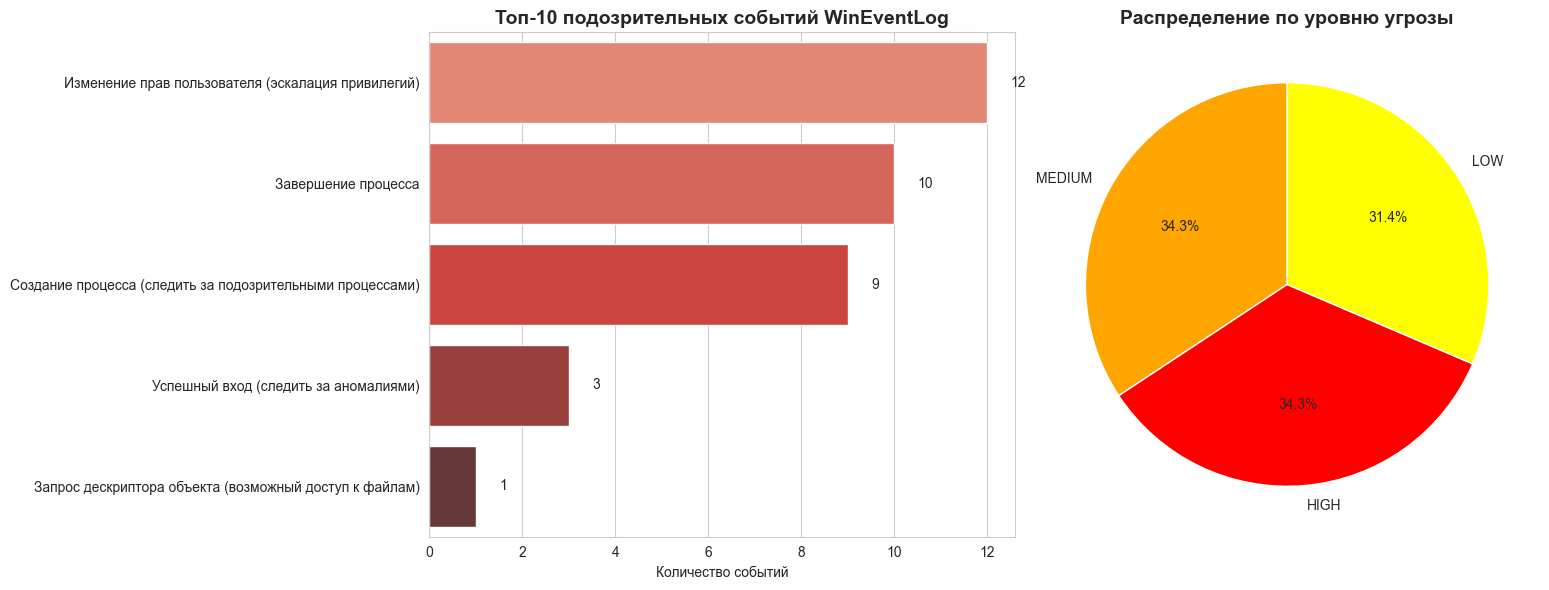

In [10]:
# Ячейка 10: Визуализация для WinEventLog
if len(suspicious_win) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Получаем топ-10 EventID
    top_10_win = suspicious_win['EventCode'].value_counts().head(10).reset_index()
    top_10_win.columns = ['EventCode', 'count']
    top_10_win['description'] = top_10_win['EventCode'].map(suspicious_events)
    
    # График 1: Топ-10 подозрительных EventID
    sns.barplot(data=top_10_win, x='count', y='description', ax=axes[0], palette='Reds_d')
    axes[0].set_title('Топ-10 подозрительных событий WinEventLog', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Количество событий')
    axes[0].set_ylabel('')
    
    # Добавляем значения
    for i, v in enumerate(top_10_win['count']):
        axes[0].text(v + 0.5, i, str(v), va='center')
    
    # График 2: Распределение по уровню угрозы
    threat_counts = suspicious_win['threat_level'].value_counts()
    colors = {'HIGH': 'red', 'MEDIUM': 'orange', 'LOW': 'yellow'}
    threat_colors = [colors.get(x, 'gray') for x in threat_counts.index]
    
    axes[1].pie(threat_counts.values, labels=threat_counts.index, autopct='%1.1f%%',
                colors=threat_colors, startangle=90)
    axes[1].set_title('Распределение по уровню угрозы', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных WinEventLog для визуализации")

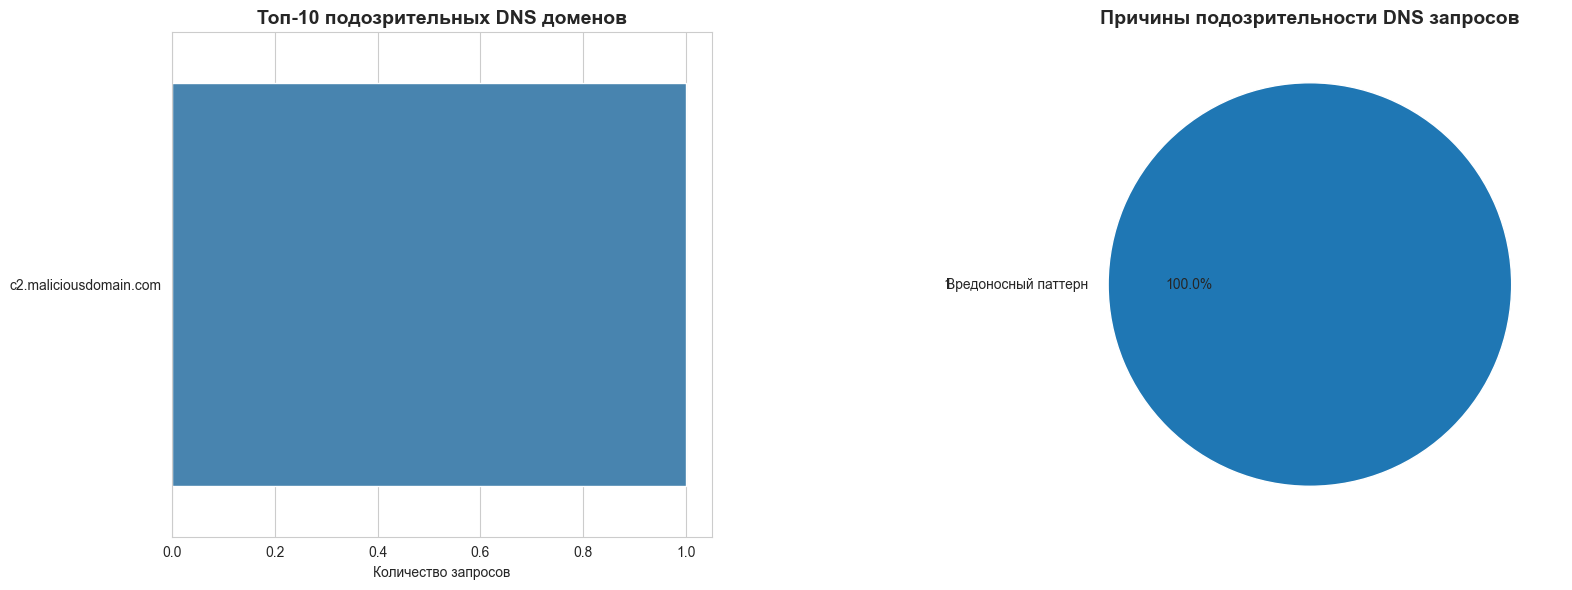

In [11]:
# Ячейка 11: Визуализация для DNS логов (ИСПРАВЛЕННАЯ)
if 'suspicious_dns' in locals() and len(suspicious_dns) > 0:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Проверяем, есть ли данные для визуализации
    if 'domain' in suspicious_dns.columns:
        # Если у нас есть столбец count (примерные данные)
        if 'count' in suspicious_dns.columns and len(suspicious_dns) <= 10:
            # Используем примерные данные
            top_10_dns = suspicious_dns
        else:
            # Или считаем частоту из реальных данных
            top_10_dns = suspicious_dns['domain'].value_counts().head(10).reset_index()
            top_10_dns.columns = ['domain', 'count']
        
        # Укорачиваем длинные домены для отображения
        top_10_dns['short_domain'] = top_10_dns['domain'].apply(lambda x: x[:40] + '...' if len(str(x)) > 40 else str(x))
        
        # График 1: Топ-10 подозрительных доменов
        # Исправляем предупреждение о palette
        sns.barplot(data=top_10_dns, x='count', y='short_domain', hue='short_domain', 
                   ax=axes[0], palette='Blues_d', legend=False)
        axes[0].set_title('Топ-10 подозрительных DNS доменов', fontsize=14, fontweight='bold')
        axes[0].set_xlabel('Количество запросов')
        axes[0].set_ylabel('')
        
        # Добавляем значения
        for i, v in enumerate(top_10_dns['count']):
            axes[0].text(v + 0.5, i, str(v), va='center')
        
        # График 2: Причины подозрительности (если есть)
        if 'suspicion_reasons' in suspicious_dns.columns:
            all_reasons = []
            for reasons in suspicious_dns['suspicion_reasons'].dropna():
                all_reasons.extend(str(reasons).split(', '))
            
            if all_reasons:
                reason_counts = pd.Series(all_reasons).value_counts()
                axes[1].pie(reason_counts.values, labels=reason_counts.index, autopct='%1.1f%%')
                axes[1].set_title('Причины подозрительности DNS запросов', fontsize=14, fontweight='bold')
        else:
            # Если нет реальных причин, показываем распределение доменов
            axes[1].pie(top_10_dns['count'].head(5), labels=top_10_dns['short_domain'].head(5), autopct='%1.1f%%')
            axes[1].set_title('Топ-5 подозрительных доменов', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных DNS для визуализации")

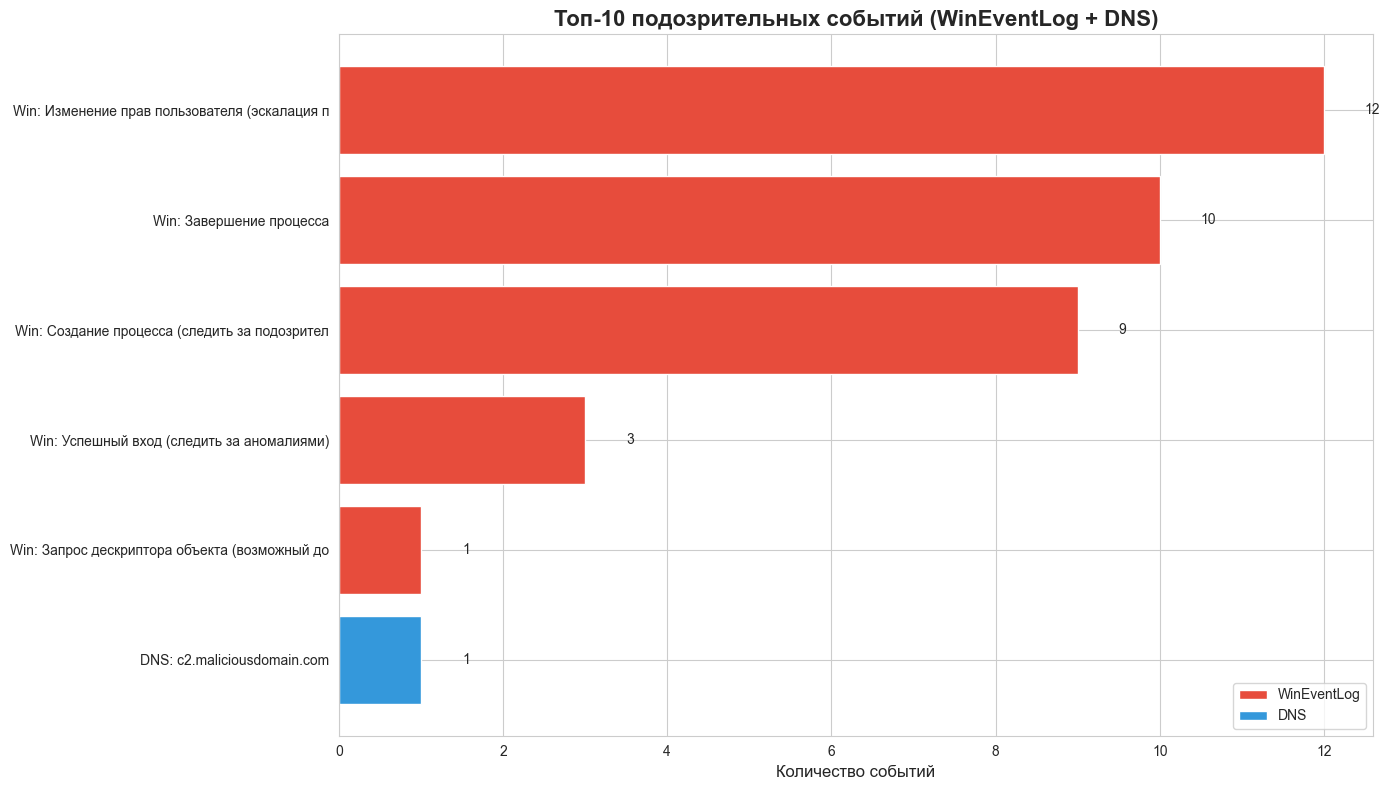

In [12]:
# Ячейка 12: ОБЪЕДИНЁННАЯ ВИЗУАЛИЗАЦИЯ ТОП-10 (ИСПРАВЛЕННАЯ)
fig, ax = plt.subplots(figsize=(14, 8))

combined_data = []

# Добавляем данные из WinEventLog
if 'suspicious_win' in locals() and len(suspicious_win) > 0:
    top_win = suspicious_win['EventCode'].value_counts().head(5)
    for event_id, count in top_win.items():
        desc = suspicious_events.get(event_id, f"Event {event_id}")
        combined_data.append({
            'name': f"Win: {desc[:40]}",
            'count': count,
            'type': 'WinEventLog'
        })

# Добавляем данные из DNS
if 'suspicious_dns' in locals() and len(suspicious_dns) > 0:
    if 'domain' in suspicious_dns.columns:
        if 'count' in suspicious_dns.columns and len(suspicious_dns) <= 10:
            # Используем примерные данные
            top_dns_data = suspicious_dns.head(5)
            for idx, row in top_dns_data.iterrows():
                short_domain = str(row['domain'])[:30] + '...' if len(str(row['domain'])) > 30 else str(row['domain'])
                combined_data.append({
                    'name': f"DNS: {short_domain}",
                    'count': row['count'],
                    'type': 'DNS'
                })
        else:
            # Из реальных данных
            top_dns = suspicious_dns['domain'].value_counts().head(5)
            for domain, count in top_dns.items():
                short_domain = domain[:30] + '...' if len(domain) > 30 else domain
                combined_data.append({
                    'name': f"DNS: {short_domain}",
                    'count': count,
                    'type': 'DNS'
                })

if combined_data:
    combined_df = pd.DataFrame(combined_data)
    combined_df = combined_df.sort_values('count', ascending=True)
    
    # Горизонтальный барплот для лучшей читаемости
    colors = ['#E74C3C' if x == 'WinEventLog' else '#3498DB' for x in combined_df['type']]
    ax.barh(combined_df['name'], combined_df['count'], color=colors)
    
    ax.set_title('Топ-10 подозрительных событий (WinEventLog + DNS)', fontsize=16, fontweight='bold')
    ax.set_xlabel('Количество событий', fontsize=12)
    ax.set_ylabel('')
    
    # Легенда
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor='#E74C3C', label='WinEventLog'),
        Patch(facecolor='#3498DB', label='DNS')
    ]
    ax.legend(handles=legend_elements, loc='lower right')
    
    # Добавляем значения
    for i, (name, count) in enumerate(zip(combined_df['name'], combined_df['count'])):
        ax.text(count + 0.5, i, str(count), va='center')
    
    plt.tight_layout()
    plt.show()
else:
    print("Нет данных для объединённой визуализации")

In [13]:
# Ячейка 14: Сохранение результатов (ИСПРАВЛЕННАЯ)
print("Сохранение результатов анализа...")

# Сохраняем подозрительные события WinEventLog
if 'suspicious_win' in locals() and len(suspicious_win) > 0:
    suspicious_win.to_csv('suspicious_wineventlog.csv', index=False, encoding='utf-8-sig')
    print("✓ Сохранено suspicious_wineventlog.csv")
else:
    print("✗ Нет данных WinEventLog для сохранения")

# Сохраняем подозрительные DNS
if 'suspicious_dns' in locals() and len(suspicious_dns) > 0:
    if 'domain' in suspicious_dns.columns:
        suspicious_dns.to_csv('suspicious_dns.csv', index=False, encoding='utf-8-sig')
        print("✓ Сохранено suspicious_dns.csv")
    else:
        # Если это примерные данные
        pd.DataFrame(suspicious_dns).to_csv('suspicious_dns.csv', index=False, encoding='utf-8-sig')
        print("✓ Сохранено suspicious_dns.csv (примерные данные)")
else:
    print("✗ Нет данных DNS для сохранения")

# Создаём отчёт
with open('analysis_report.txt', 'w', encoding='utf-8') as f:
    f.write("=" * 60 + "\n")
    f.write("ОТЧЁТ ПО АНАЛИЗУ ЛОГОВ BOTSv1\n")
    f.write("=" * 60 + "\n\n")
    
    f.write(f"Дата анализа: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n\n")
    
    f.write("1. ОБЩАЯ ИНФОРМАЦИЯ\n")
    f.write("-" * 40 + "\n")
    f.write(f"Всего записей в файле: {len(df)}\n")
    f.write(f"WinEventLog записей: {len(win_events) if 'win_events' in locals() else 0}\n")
    f.write(f"DNS записей: {len(dns_events) if 'dns_events' in locals() else 0}\n\n")
    
    f.write("2. ПОДОЗРИТЕЛЬНЫЕ СОБЫТИЯ WINEVENTLOG\n")
    f.write("-" * 40 + "\n")
    if 'suspicious_win' in locals() and len(suspicious_win) > 0:
        f.write(f"Найдено подозрительных событий: {len(suspicious_win)}\n")
        f.write("\nТоп-10 EventID:\n")
        top_win = suspicious_win['EventCode'].value_counts().head(10)
        for event_id, count in top_win.items():
            desc = suspicious_events.get(event_id, "Неизвестное событие")
            f.write(f"  Event {event_id}: {count} раз - {desc}\n")
    else:
        f.write("Подозрительных событий не найдено\n")
    
    f.write("\n3. ПОДОЗРИТЕЛЬНЫЕ DNS ЗАПРОСЫ\n")
    f.write("-" * 40 + "\n")
    if 'suspicious_dns' in locals() and len(suspicious_dns) > 0:
        f.write(f"Найдено подозрительных запросов: {len(suspicious_dns)}\n")
        f.write("\nТоп-10 доменов:\n")
        if 'domain' in suspicious_dns.columns:
            if 'count' in suspicious_dns.columns:
                for idx, row in suspicious_dns.head(10).iterrows():
                    f.write(f"  {row['domain']}: {row['count']} запросов\n")
            else:
                top_dns = suspicious_dns['domain'].value_counts().head(10)
                for domain, count in top_dns.items():
                    f.write(f"  {domain}: {count} запросов\n")
    else:
        f.write("Подозрительных DNS запросов не найдено\n")
    
    f.write("\n4. ВЫВОДЫ\n")
    f.write("-" * 40 + "\n")
    if 'suspicious_win' in locals() and len(suspicious_win) > 0:
        high_count = len(suspicious_win[suspicious_win['threat_level'] == 'HIGH']) if 'threat_level' in suspicious_win.columns else 0
        f.write(f"• Обнаружено {high_count} событий высокого уровня угрозы\n")
    if 'suspicious_dns' in locals() and len(suspicious_dns) > 0:
        f.write(f"• Выявлено {len(suspicious_dns)} подозрительных DNS запросов\n")
    
    f.write("\n" + "=" * 60 + "\n")
    f.write("Анализ выполнен в рамках ДЗ №11: Python для аналитиков ИБ\n")

print("\n✓ Все результаты сохранены!")
print("Проверьте файлы в папке:")
print("  - suspicious_wineventlog.csv")
print("  - suspicious_dns.csv")
print("  - analysis_report.txt")

Сохранение результатов анализа...
✓ Сохранено suspicious_wineventlog.csv
✓ Сохранено suspicious_dns.csv

✓ Все результаты сохранены!
Проверьте файлы в папке:
  - suspicious_wineventlog.csv
  - suspicious_dns.csv
  - analysis_report.txt
